# 0. Configuration

In [1]:
# data frame
import pandas as pd
import numpy as np

# statistics
import scipy.stats as stats
from scipy.stats import ttest_ind, chi2_contingency, binomtest

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
ab_test_df = pd.read_excel('artea.xlsx', sheet_name='AB_test')

treatment = ab_test_df[ab_test_df['test_coupon'] == 1]
control = ab_test_df[ab_test_df['test_coupon'] == 0]

covariates = ['channel_acq', 'num_past_purch', 'spent_last_purchase', 
              'weeks_since_visit', 'browsing_minutes', 'shopping_cart']

print(f"Total observations: {len(ab_test_df)}")
print(f"Treatment: {len(treatment)}, Control: {len(control)}")

Total observations: 5000
Treatment: 2502, Control: 2498


# 1. Group Size Check

If randomization was truly 50/50, the observed split should be consistent with a fair coin flip. We use a binomial test to verify.

In [3]:
n_total = len(ab_test_df)
n_treatment = len(treatment)

result = binomtest(n_treatment, n_total, p=0.5)

print(f"Treatment group: {n_treatment} / {n_total} ({n_treatment/n_total:.4f})")
print(f"Binomial test p-value: {result.pvalue:.4f}")
print(f"95% CI for treatment proportion: [{result.proportion_ci().low:.4f}, {result.proportion_ci().high:.4f}]")
print(f"\nConclusion: {'Group sizes are consistent with 50/50 randomization.' if result.pvalue > 0.05 else 'Group sizes deviate significantly from 50/50.'}")

Treatment group: 2502 / 5000 (0.5004)
Binomial test p-value: 0.9662
95% CI for treatment proportion: [0.4864, 0.5144]

Conclusion: Group sizes are consistent with 50/50 randomization.


# 2. Covariate Balance Table

## 2.1 Continuous Covariates — Two-Sample t-Tests

In [4]:
continuous_covs = ['num_past_purch', 'spent_last_purchase', 'weeks_since_visit', 'browsing_minutes']

ttest_records = []
for col in continuous_covs:
    t_mean = treatment[col].mean()
    c_mean = control[col].mean()
    t_stat, p_val = ttest_ind(treatment[col], control[col])
    ttest_records.append({
        'covariate': col,
        'treatment_mean': t_mean,
        'control_mean': c_mean,
        'difference': t_mean - c_mean,
        't_statistic': t_stat,
        'p_value': p_val,
        'balanced (p>0.05)': 'Yes' if p_val > 0.05 else 'No'
    })

ttest_df = pd.DataFrame(ttest_records).set_index('covariate')
ttest_df

,treatment_mean,control_mean,difference,t_statistic,p_value,balanced (p>0.05)
covariate,,,,,,
num_past_purch,2.0915,2.0196,0.0719,0.9930,0.3208,Yes
spent_last_purchase,58.1558,56.6895,1.4663,0.9347,0.3500,Yes
weeks_since_visit,3.2570,3.1829,0.0740,1.1591,0.2465,Yes
browsing_minutes,13.6707,13.7074,-0.0367,-0.1863,0.8522,Yes


## 2.2 Categorical Covariates — Chi-Squared Tests

In [5]:
categorical_covs = ['channel_acq', 'shopping_cart']

chi2_records = []
for col in categorical_covs:
    ct = pd.crosstab(ab_test_df[col], ab_test_df['test_coupon'])
    chi2, p_val, dof, expected = chi2_contingency(ct)
    chi2_records.append({
        'covariate': col,
        'chi2_statistic': chi2,
        'degrees_of_freedom': dof,
        'p_value': p_val,
        'balanced (p>0.05)': 'Yes' if p_val > 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_records).set_index('covariate')
chi2_df

,chi2_statistic,degrees_of_freedom,p_value,balanced (p>0.05)
covariate,,,,
channel_acq,1.7821,4,0.7757,Yes
shopping_cart,1.1278,1,0.2882,Yes


In [6]:
# contingency tables
for col in categorical_covs:
    ct = pd.crosstab(ab_test_df[col], ab_test_df['test_coupon'])
    ct.columns = ['Control', 'Treatment']
    print(f"\n--- {col} ---")
    print(ct)


--- channel_acq ---
             Control  Treatment
channel_acq                    
1               1027       1008
2                515        544
3                785        767
4                113        125
5                 58         58

--- shopping_cart ---
               Control  Treatment
shopping_cart                    
0                 1749       1787
1                  749        715


# 3. Standardized Mean Differences (Love Plot)
Cohen's d measures the effect size of the difference between groups. For a well-randomized experiment, all |SMD| should be below 0.1.

In [7]:
smd_records = []
for col in covariates:
    t_mean = treatment[col].mean()
    c_mean = control[col].mean()
    t_std = treatment[col].std()
    c_std = control[col].std()
    pooled_std = np.sqrt((t_std**2 + c_std**2) / 2)
    cohens_d = (t_mean - c_mean) / pooled_std
    smd_records.append({'covariate': col, 'SMD (Cohen\'s d)': cohens_d})

smd_df = pd.DataFrame(smd_records).set_index('covariate')
smd_df

,SMD (Cohen's d)
covariate,
channel_acq,0.0094
num_past_purch,0.0281
spent_last_purchase,0.0264
weeks_since_visit,0.0328
browsing_minutes,-0.0053
shopping_cart,-0.0309


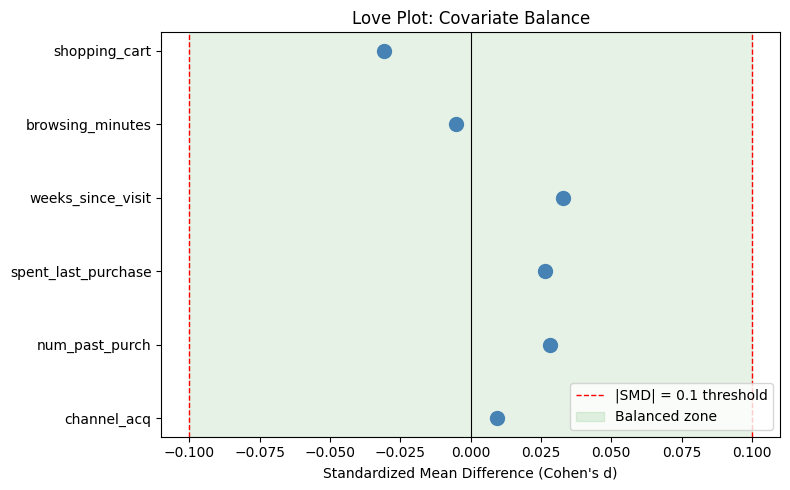

In [8]:
# Love plot
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = range(len(smd_df))
ax.scatter(smd_df["SMD (Cohen's d)"], y_pos, color='steelblue', s=100, zorder=3)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1, label='|SMD| = 0.1 threshold')
ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1)
ax.axvspan(-0.1, 0.1, alpha=0.1, color='green', label='Balanced zone')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(smd_df.index)
ax.set_xlabel("Standardized Mean Difference (Cohen's d)")
ax.set_title('Love Plot: Covariate Balance')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# 4. Distributional Balance (Visual)

## 4.1 Continuous Covariates — KDE Overlays

/Users/chohasong/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chohasong/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chohasong/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chohasong/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

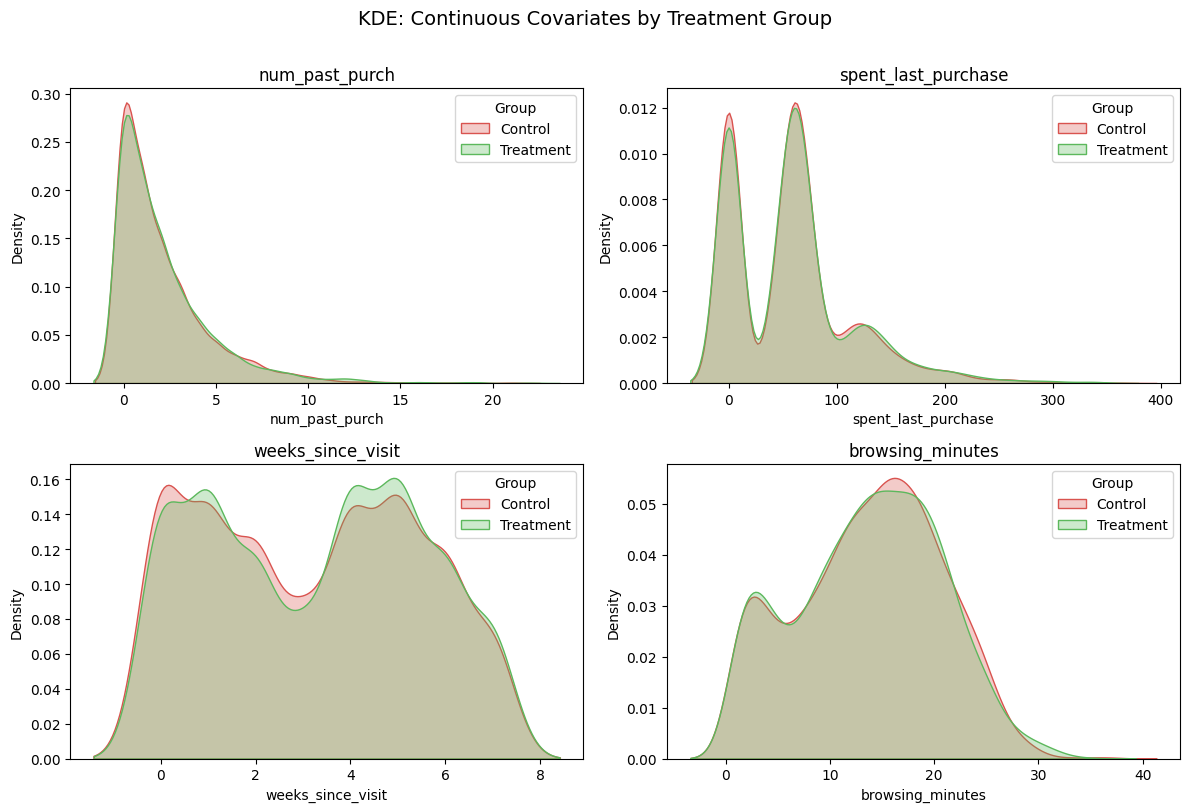

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_covs):
    sns.kdeplot(data=control[col], ax=axes[i], color='#d9534f', label='Control', fill=True, alpha=0.3)
    sns.kdeplot(data=treatment[col], ax=axes[i], color='#5cb85c', label='Treatment', fill=True, alpha=0.3)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Group')

plt.suptitle('KDE: Continuous Covariates by Treatment Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4.2 Categorical Covariates — Grouped Bar Charts

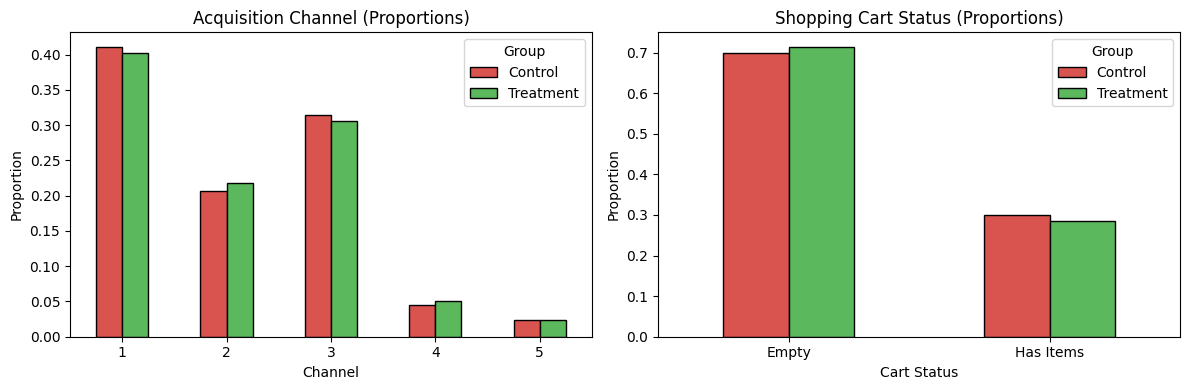

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# channel_acq — normalize to proportions for fair comparison
channel_ct = pd.crosstab(ab_test_df['channel_acq'], ab_test_df['test_coupon'], normalize='columns')
channel_ct.columns = ['Control', 'Treatment']
channel_ct.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[0].set_title('Acquisition Channel (Proportions)')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Group')
axes[0].tick_params(axis='x', rotation=0)

# shopping_cart
cart_ct = pd.crosstab(ab_test_df['shopping_cart'], ab_test_df['test_coupon'], normalize='columns')
cart_ct.columns = ['Control', 'Treatment']
cart_ct.index = ['Empty', 'Has Items']
cart_ct.plot(kind='bar', ax=axes[1], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[1].set_title('Shopping Cart Status (Proportions)')
axes[1].set_xlabel('Cart Status')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Group')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 5. Joint Balance Test (Omnibus)
Individual tests check one covariate at a time. The omnibus test checks whether all covariates **jointly** predict treatment assignment — if they can, randomization may have failed.

Under the null hypothesis of proper randomization, the sum of squared t-statistics follows a chi-squared distribution with degrees of freedom equal to the number of covariates.

In [11]:
# compute t-statistics for all covariates
t_stats = []
for col in covariates:
    t_stat, _ = ttest_ind(treatment[col], control[col])
    t_stats.append(t_stat)

# omnibus chi-squared test: sum of squared t-stats ~ chi2(k)
chi2_omnibus = sum(t**2 for t in t_stats)
k = len(covariates)
p_omnibus = 1 - stats.chi2.cdf(chi2_omnibus, df=k)

print(f"Omnibus Chi-Squared Statistic: {chi2_omnibus:.4f}")
print(f"Degrees of Freedom: {k}")
print(f"P-value: {p_omnibus:.4f}")
print(f"\nConclusion: {'Covariates do NOT jointly predict treatment — randomization appears valid.' if p_omnibus > 0.05 else 'Covariates jointly predict treatment — potential randomization issue.'}")

Omnibus Chi-Squared Statistic: 4.5425
Degrees of Freedom: 6
P-value: 0.6037

Conclusion: Covariates do NOT jointly predict treatment — randomization appears valid.


# 6. Conclusion

In [12]:
print("=" * 60)
print("RANDOMIZATION BALANCE CHECK SUMMARY")
print("=" * 60)

# group sizes
print(f"\n1. Group Sizes: Treatment={len(treatment)}, Control={len(control)}")
print(f"   Binomial test p-value: {binomtest(len(treatment), len(ab_test_df), 0.5).pvalue:.4f} → PASS")

# individual covariate tests
print(f"\n2. Individual Covariate Balance:")
all_pass = True
for col in continuous_covs:
    _, p = ttest_ind(treatment[col], control[col])
    status = "PASS" if p > 0.05 else "FAIL"
    if p <= 0.05:
        all_pass = False
    print(f"   {col:25s} t-test p={p:.4f} → {status}")

for col in categorical_covs:
    ct = pd.crosstab(ab_test_df[col], ab_test_df['test_coupon'])
    _, p, _, _ = chi2_contingency(ct)
    status = "PASS" if p > 0.05 else "FAIL"
    if p <= 0.05:
        all_pass = False
    print(f"   {col:25s} chi2   p={p:.4f} → {status}")

# SMD check
print(f"\n3. Standardized Mean Differences:")
all_smd_ok = True
for _, row in smd_df.iterrows():
    smd_val = row["SMD (Cohen's d)"]
    status = "PASS" if abs(smd_val) < 0.1 else "FAIL"
    if abs(smd_val) >= 0.1:
        all_smd_ok = False
    print(f"   {_:25s} SMD={smd_val:+.4f} → {status}")

# omnibus
print(f"\n4. Joint (Omnibus) Test: chi2={chi2_omnibus:.4f}, p={p_omnibus:.4f} → {'PASS' if p_omnibus > 0.05 else 'FAIL'}")

print("\n" + "=" * 60)
if all_pass and all_smd_ok and p_omnibus > 0.05:
    print("OVERALL: All checks passed. Randomization appears valid.")
else:
    print("OVERALL: Some checks failed. Investigate potential imbalances.")
print("=" * 60)

RANDOMIZATION BALANCE CHECK SUMMARY

1. Group Sizes: Treatment=2502, Control=2498
   Binomial test p-value: 0.9662 → PASS

2. Individual Covariate Balance:
   num_past_purch            t-test p=0.3208 → PASS
   spent_last_purchase       t-test p=0.3500 → PASS
   weeks_since_visit         t-test p=0.2465 → PASS
   browsing_minutes          t-test p=0.8522 → PASS
   channel_acq               chi2   p=0.7757 → PASS
   shopping_cart             chi2   p=0.2882 → PASS

3. Standardized Mean Differences:
   channel_acq               SMD=+0.0094 → PASS
   num_past_purch            SMD=+0.0281 → PASS
   spent_last_purchase       SMD=+0.0264 → PASS
   weeks_since_visit         SMD=+0.0328 → PASS
   browsing_minutes          SMD=-0.0053 → PASS
   shopping_cart             SMD=-0.0309 → PASS

4. Joint (Omnibus) Test: chi2=4.5425, p=0.6037 → PASS

OVERALL: All checks passed. Randomization appears valid.
